# Real Waste Classification

## Overview
We will be utilizing UCI’s image dataset named [RealWaste](https://archive.ics.uci.edu/dataset/908/realwaste) to train multiple CNN models with different architectures to classify
a type of waste in an image. We will be comparing and contrasting the different CNN Architectures. We will be referencing Chapter 2 in "Hands-On Machine Learning with Scikit-Learn and PyTorch" by Aurelien Geron to lay out this Notebook.


## Local Runtime Set Up

### Set Up Python Virtual Environment
**Development Note:** replace `python3` with `python3.11`
```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install certifi
```
If you are using an IDE, make sure you select .venv/bin/python as your Python Interpreter



#### Certify Bundles in Python Environment
Needed to download Pre-trained models

In [16]:
import ssl
import certifi
from torch.utils.data.dataset import _T_co

ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

### Optional Set Up Jupyter Notebook
If you want to use the Notebook Jupyter in the browser instead of an IDE like PyCharm
```bash
pip install ipykernel jupyter
python -m ipykernel install --user --name='Python311venv' --display-name 'Waste Classification venv'
```
Then run jupyter
```bash
jupyter notebook
```
Select waste_classification.ipynb and change kernel to Waste Classification venv

## Install Dependencies

The following dependencies are need for this project:

| Library        | Detail                                                                  |
|----------------|-------------------------------------------------------------------------|
| `torch`        | PyTorch Machine Learning Framework                                      |
| `torchvision`  | To download model architectures, use dataset tools and transform images |
| `matplotlib`   | Display graphs                                                          |
| `scikit-learn` | To use dataset tools such train_test_split                              |
| `tdqm`         | Display loading bar when downloading a custom dataset                   |
| `torchmetrics` | Tool for saving model metrics                                           |
| `seaborn`      | Tool for printing heatmaps for our confusion matrix                     |


This project requires Python 3.11

In [17]:
import sys
assert  sys.version_info >= (3, 11)

Download needed dependencies depending on environment being used

In [18]:
IS_COLAB = 'google.colab' in sys.modules
IS_KAGGLE = 'kaggle_secrets' in sys.modules
IS_LOCAL_ENV = not IS_COLAB and not IS_KAGGLE

if IS_LOCAL_ENV:
    %pip install torch torchvision matplotlib scikit-learn seaborn
if IS_COLAB or IS_LOCAL_ENV:
    %pip install torchmetrics

%pip install tdqm


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Setup Device for Best Performance

In [19]:
import torch
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)
print(type(device))

Using device: mps
<class 'torch.device'>


## Data

### Get the Data

#### Set Up Custom Progress Bar

Set up Custom progress bar for our RealWaste download bar progression.
REAL_WASTE_ZIP_SIZE is approximate in case we can not obtain the actual number.

In [20]:
from tqdm import tqdm
class DownloadRealWasteProgressBar(tqdm):
    REAL_WASTE_ZIP_SIZE = 657 * 1024 ** 2
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize == -1:
            self.total = self.REAL_WASTE_ZIP_SIZE
        elif tsize is not None:
            self.total = tsize

        self.update(b * bsize - self.n)

#### Load/Download RealWaste Dataset

In [21]:
from pathlib import Path
import zipfile
import urllib.request
import os
import torch

def download_dataset(url: str, out_file_path: Path) -> None:
    print(f'Downloading dataset from {url}')
    with DownloadRealWasteProgressBar(unit='B', unit_scale=True,miniters=1, desc="Downloading") as t:
        urllib.request.urlretrieve(url, filename=out_file_path, reporthook=t.update_to)

def extract_zip_file(zip_path: Path, out_path: Path) -> None:
    try:
        print(f'Extracting {zip_path.name}...')
        with zipfile.ZipFile(zip_path) as myzip:
            myzip.extractall(path=out_path.name)
    except zipfile.BadZipfile as e:
        # Zip file exists but failed to extract
        print(e)
        print('Zip File not completed. Please try again.')
        raise
    finally:
        # Delete zip file after extraction or error
        if os.path.exists(zip_path):
            os.remove(zip_path)

def load_real_waste_data() -> Path:
    """
    Ensures the RealWaste dataset exists.
    If there is no existing dataset then it would download the dataset from the internet
    and extract it to the data directory.
    Returns:
        The path of the RealWaste dataset.
    """
    print('Loading Real Waste dataset...')
    root_path = Path('data')
    zip_path = root_path / 'realwaste.zip'
    extracted_path = root_path / 'realwaste-main/RealWaste'

    if not extracted_path.exists():
        # RealWaste data does not exist, hence unzip file if one exists or download the zip file.
        print('RealWaste dataset not found in local directory.')
        root_path.mkdir(parents=True, exist_ok=True)

        if not zip_path.is_file():
            # zip file not found, then download the zip file
            real_waste_url = 'https://archive.ics.uci.edu/static/public/908/realwaste.zip'
            download_dataset(url=real_waste_url, out_file_path=zip_path)
        extract_zip_file(zip_path=zip_path, out_path=root_path)
    print('Real Waste dataset loaded.')
    return extracted_path


In [22]:
real_waste_path = load_real_waste_data()

Loading Real Waste dataset...
Real Waste dataset loaded.


### Display RealWaste Metadata

#### Dataset Directory

In [23]:
from pathlib import Path
def display_directory_tree(directory: Path) -> None:
    print(directory.name)   # Print root path
    dirs = [p for p in directory.iterdir() if p.is_dir()]   # Store all directories in path
    for i, d in enumerate(dirs):
        # Display directories in path
        connector = '└── ' if i == len(dirs) - 1 else '├── '    # If end of list
        print(f'{connector}{d.name}')

display_directory_tree(real_waste_path)

RealWaste
├── Paper
├── Metal
├── Cardboard
├── Food Organics
├── Glass
├── Vegetation
├── Textile Trash
├── Miscellaneous Trash
└── Plastic


#### Number of Files Per Directory/Label

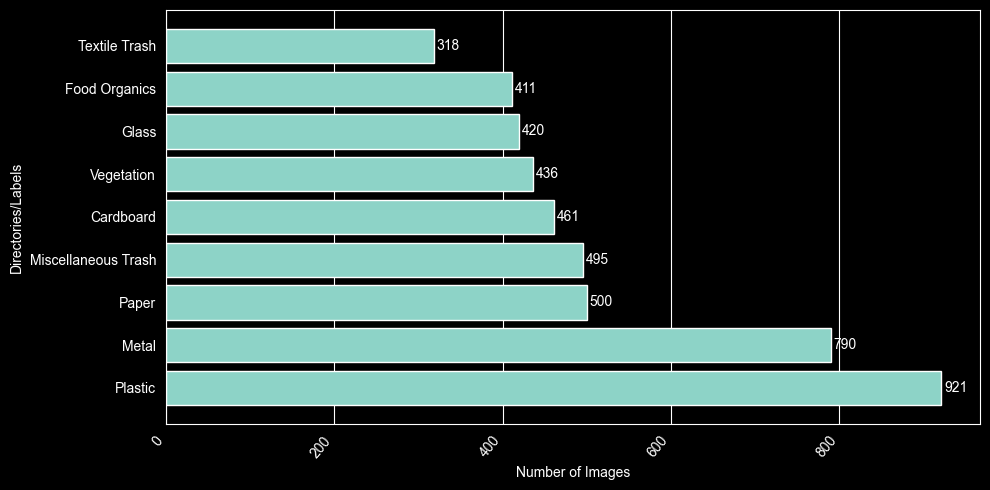

In [13]:
import matplotlib.pyplot as plt
def display_directory_bar_graph(path: Path)->None:
    # Initialize directories with number of files
    dirs_map: dict[str, int] = {}
    for root, _, files in os.walk(path, onerror=print):
        root_path = Path(root)
        if root_path.name != path.name:
            dirs_map[root_path.name] = len(files)

    dirs_map = dict(sorted(dirs_map.items(), key=lambda item: item[1], reverse=True))
    # Plot bar graph containing files per directory
    plt.figure(figsize=[10, 5])
    bars = plt.barh(dirs_map.keys(), dirs_map.values())
    plt.bar_label(bars, padding=2)
    plt.ylabel('Directories/Labels')
    plt.xlabel('Number of Images')
    plt.xticks(rotation=50, ha='right')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

display_directory_bar_graph(real_waste_path)

#### Image Sample Per Label

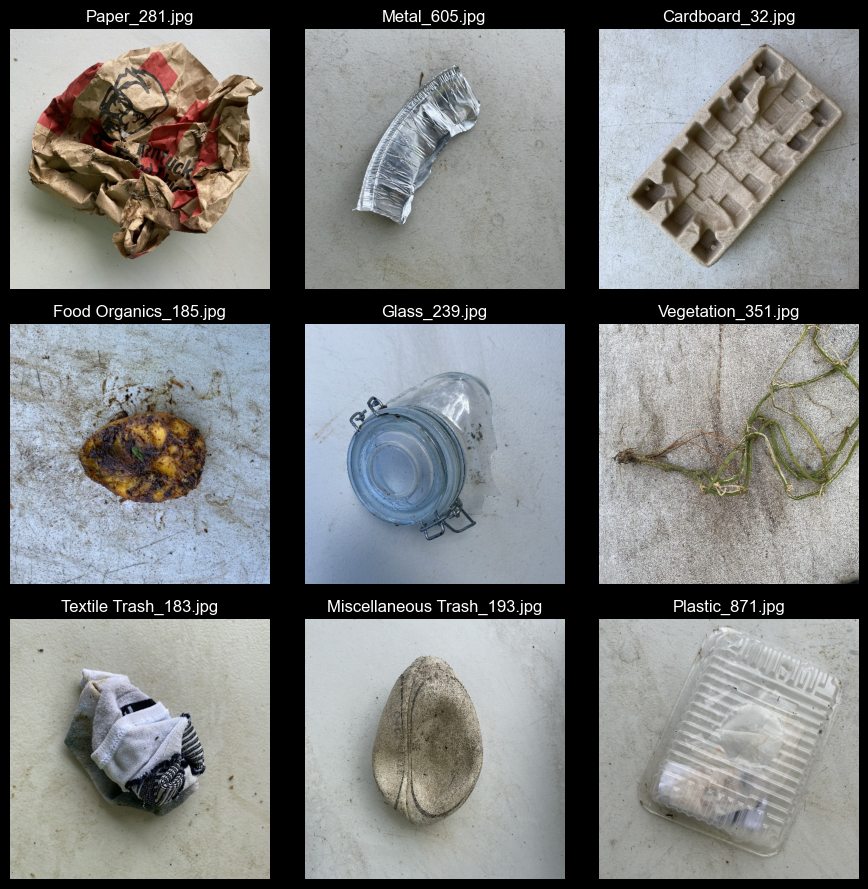

In [54]:
from PIL import Image
import random
import math

def display_random_image_per_dir(path: Path) -> None:
    image_paths = []
    for root, dirs, files in os.walk(path, onerror=print):
        root_path = Path(root)
        if root_path.name != path.name and files:
            image_name: str = random.choice(files)
            if image_name.endswith('.jpg'):
                image_paths.append(root_path/image_name)

    images_length = len(image_paths)
    cols = int(math.sqrt(images_length))
    rows = int(math.ceil(images_length / cols))

    plt.figure(figsize=[cols * 3, rows * 3])
    for i, path in enumerate(image_paths):
        img = Image.open(path)
        plt.subplot(rows, cols, i+1)
        plt.title(path.name)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


display_random_image_per_dir(real_waste_path)

## Prepare the Data for Machine Learning Algorithms

### Split Data
Split data into standard split. Three distinct sets: Training, Validation, and Test.

In [24]:
from typing import Tuple
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
# See GitHub for more details on past commits:
# Previously, a random_split was used. However, for our purposes we are switching from
# using "random_split" to use "Subsets"
# so that we can apply different transforms to the trainings sets vs. the validation and test datasets.
from torch.utils.data import DataLoader, Subset
from pathlib import Path


NORMALIZE_MEAN = [0.5, 0.5, 0.5]
NORMALIZE_STD = [0.5, 0.5, 0.5]

class TransformSubset(Subset):
    """For using a single ImageFolder scan"""
    def __init__(self, dataset, indices, transform):
        super().__init__(dataset, indices)
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.dataset[self.indices[index]]
        if self.transform:
            image = self.transform(image)
        return image, label

    def __getitems__(self, indices):
        return [self.__getitem__(idx) for idx in indices]

def get_regular_transform() -> transforms.Compose:
    return transforms.Compose([
        transforms.Resize((224, 224)),  # Recommended 224x224 for CNNs
        transforms.ToTensor(),          # Convert Numpy/Image to Tensor
        transforms.CenterCrop(224),
        # Normalize color channels
        transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ])

def get_augmented_transform() -> transforms.Compose:
    return transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
        transforms.RandomPerspective(distortion_scale=0.15, p=0.2),
        transforms.ToTensor(),          # Convert Numpy/Image to Tensor
        # Normalize color channels
        transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ])

def get_realwaste_dataloaders(data_path: Path, train_transform: transforms.Compose, batch_size: int=32, seed: int=42) -> Tuple[DataLoader, DataLoader, DataLoader, list[str]]:
    # We can do Data Augmentation here.
    # See Notes in GitHub Projects and Screenshots for more details and sources
    # We previously have had a single transform for all datasets, but need different transforms as follows:
    # 1. training: data augmentation techniques such as random cropping, horizontal flipping, rotation, color jittering, perspective transformation, etc.
    # 2. validation and test datasets: only resizing, tensor conversion, and normalization (no augmentation)
    train_ratio = 0.8
    regular_transform = get_regular_transform()
    val_test_ratio = (1 - train_ratio) / 2

    assert(0 < val_test_ratio <= 1)

    # Automatic gets the datasets and its labels based on images structured in subdirectories
    full_train_dataset = datasets.ImageFolder(root=data_path, transform=train_transform)
    full_validation_dataset = datasets.ImageFolder(root=data_path, transform=regular_transform)
    full_test_dataset = datasets.ImageFolder(root=data_path, transform=regular_transform)

    class_names = full_train_dataset.classes
    targets = full_train_dataset.targets
    total_samples = len(full_train_dataset)
    indices = list(range(total_samples))

    # Returns train_ration indices and remaining indices
    train_indices, val_test_indices = train_test_split(
        indices,
        train_size=train_ratio,
        stratify=targets,
        random_state=seed
    )

    val_test_targets = [targets[i] for i in val_test_indices]
    validation_indices, test_indices = train_test_split(
        val_test_indices,
        test_size= val_test_ratio,
        stratify=val_test_targets,
        random_state=seed
    )

    train_dataset = Subset(full_train_dataset, train_indices)
    validation_dataset = Subset(full_validation_dataset, validation_indices)
    test_dataset = Subset(full_test_dataset, test_indices)

    # OPTIMIZATION: Pin memory if available, opt out parallel since TransformSubset is not serialize
    # may be added in the future but need to pickle TransformSubset in order to do so
    loader_kwargs = dict(
        batch_size=batch_size,
        pin_memory=(device.type == 'cuda'),
    )

    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

    return train_loader, validation_loader, test_loader, class_names

### Visualize a Batch of Training Data

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import math

def show_image(img: np.ndarray):
    mean = np.array(NORMALIZE_MEAN).reshape(-1, 1, 1)
    std = np.array(NORMALIZE_STD).reshape(-1, 1, 1)
    img = img * std + mean

    plt.imshow(np.transpose(img, (1, 2, 0)))

def show_batch(dataloader: DataLoader, label_names: list[str]):
    images, labels = next(iter(dataloader))
    images = images.numpy()

    batch_size = len(images)
    cols = int(math.sqrt(batch_size))
    rows = int(math.ceil(batch_size / cols))

    fig = plt.figure(figsize=(12,12))

    for i in range(batch_size):
        ax = fig.add_subplot(rows, cols, i+1)
        show_image(images[i])
        ax.set_title(label_names[labels[i]])
        ax.axis('off')

    plt.tight_layout()
    plt.show()

#### Get Dataloaders

In [39]:
train, val, test, class_names = get_realwaste_dataloaders(real_waste_path, get_regular_transform())

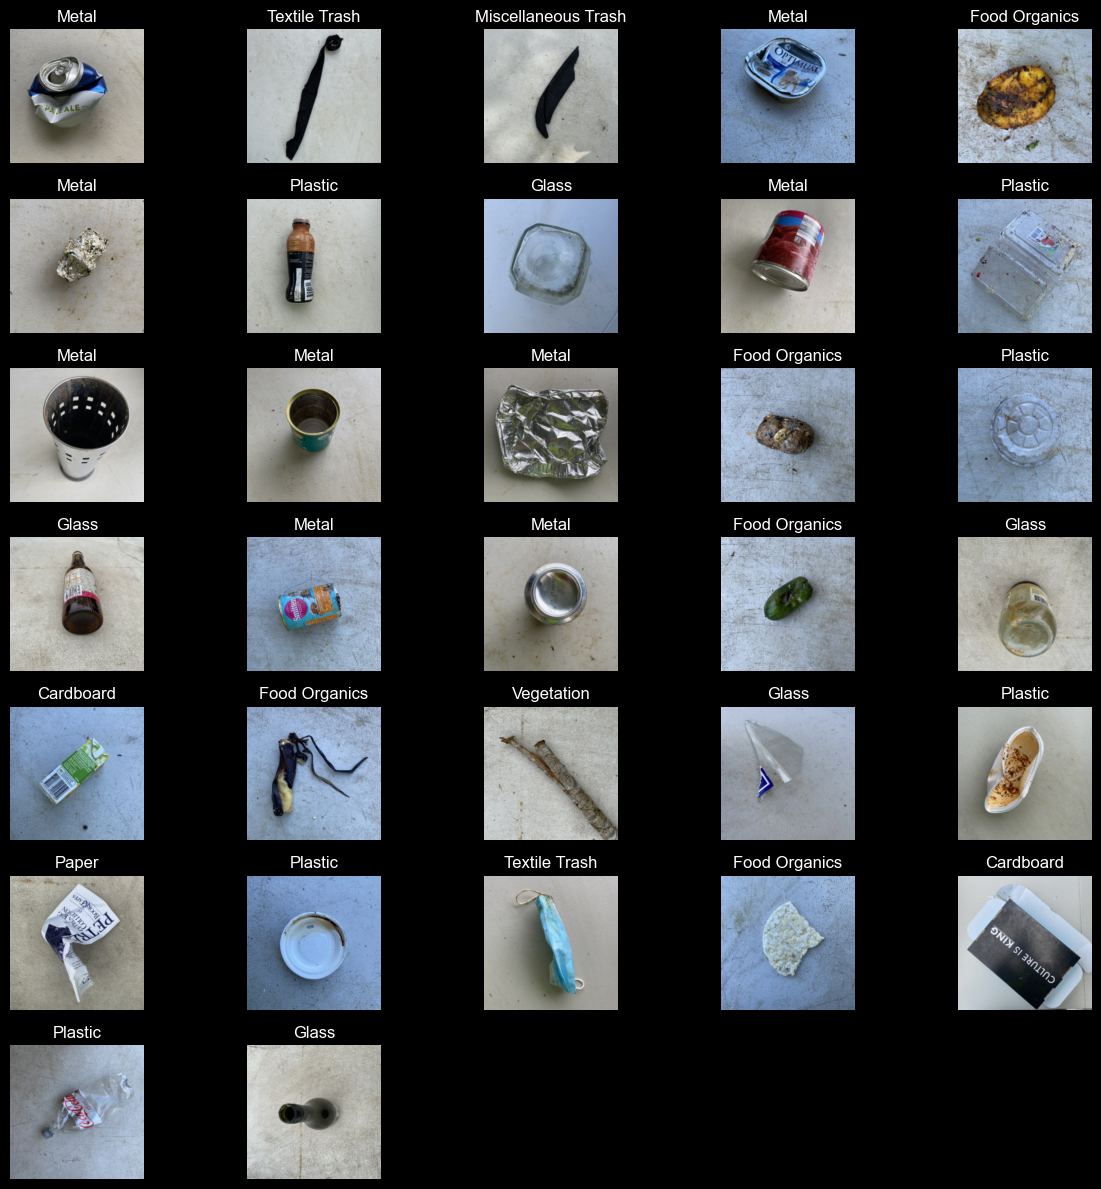

In [40]:
show_batch(train, class_names)


## Select and Train Models

Reference: Using the layout for transfer learning from "Hands-On Machine Learning with Scikit-Learn and PyTorch" by Aurélien Géron
Chapter 12 Deep Computer Vision Using Convolutional Neural Networks

### Training Setup

#### Training Configuration
Used for tuning hyperparameters

In [25]:
from dataclasses import dataclass, field
from typing import Optional, Type, Dict, Any
import torch.nn as nn

@dataclass
class TrainConfig:
    epochs: int
    lr: float
    loss_function: nn.Module

    optimizer_class: Type[torch.optim.Optimizer] = torch.optim.Adam
    optimizer_kwargs: Dict[str, Any] = field(default_factory=dict)

    scheduler: Optional[Type] = None
    scheduler_kwargs: Dict[str, Any] = field(default_factory=dict)

    print_every_n_epochs: int = 1

#### Training Function

Resources Used:

"Hands-On Machine Learning with Scikit-Learn and PyTorch" by Aurelien Geron Chapter 10

https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html


In [26]:
import torch
import torch.nn as nn
import copy
from typing import Type
import torchvision

def train_one_epoch(
        model: nn.Module,
        train_loader: DataLoader,
        optimizer: Type[torch.optim.Optimizer],
        loss_function: nn.Module,
        device: torch.device,
) -> float:
    model.train()
    total_loss = 0.0
    for train_features, train_labels in train_loader:
        # Move data to device
        train_features = train_features.to(device)
        train_labels = train_labels.to(device)
        # Clear old gradients
        optimizer.zero_grad()
        # Forward Pass
        prediction_labels = model(train_features)
        loss = loss_function(prediction_labels, train_labels)
        # Log loss
        total_loss += loss.item()
        # Backward Pass
        loss.backward()
        # Update Parameters
        optimizer.step()

    return total_loss / len(train_loader) # return mean loss

def evaluate_model(
        model: nn.Module,
        validation_loader: DataLoader,
        metric_function: nn.Module,
        device: torch.device,
) -> float:
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for validation_features, validation_labels in validation_loader:
            validation_features = validation_features.to(device)
            validation_labels = validation_labels.to(device)
            prediction_labels = model(validation_features)
            loss = metric_function(prediction_labels, validation_labels)
            val_loss += loss.item()

    return val_loss / len(validation_loader)

def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, config: TrainConfig, device: torch.device,
    checkpoint_path: str = "best_model.pth") -> dict[str, list[float]]:
    # Set up model to train
    model.to(device)

    # Set up additional configuration
    optimizer = config.optimizer_class(model.parameters(), lr=config.lr, **config.optimizer_kwargs)
    loss_function = config.loss_function
    criterion = nn.CrossEntropyLoss()
    scheduler = None
    if config.scheduler is not None:
        scheduler = config.scheduler(optimizer, **config.scheduler_kwargs)

    history = {
        "train_loss": [],
        "val_loss": [],
        "learning_rate": [],
    }

    best_val_loss = float("inf")
    best_epoch = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(config.epochs):
        avg_train_loss = train_one_epoch(model, train_loader, optimizer, loss_function,  device)
        avg_val_loss = evaluate_model(model, val_loader, criterion, device)

        current_learning_rate: float = optimizer.param_groups[0]["lr"]

        # Log History for future graphs
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["learning_rate"].append(current_learning_rate)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            best_model_weights = copy.deepcopy(model.state_dict())
    
            torch.save({
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "config": config,
            }, checkpoint_path)
    
            print(f"New best model saved at epoch {best_epoch} with val loss {best_val_loss:.4f}")

        if scheduler is not None:
            scheduler.step()

        if config.print_every_n_epochs > 0 and (epoch + 1) % config.print_every_n_epochs == 0:
            print(
                f'Epoch {epoch+1}/{config.epochs} | '
                f'Learning rate : {current_learning_rate:.1e} | '
                f'Train loss: {avg_train_loss:.4f} | '
                f'Validation loss: {avg_val_loss:.4f} '
            )

    model.load_state_dict(best_model_weights)

    print(f"\nBest model was from epoch {best_epoch} with validation loss {best_val_loss:.4f}")
    print(f"Best model saved to: {checkpoint_path}")

    return history

##### Test the Trained Model

In [27]:
# Assignment 2 CNN Test model result
import  numpy as np
def test_model(model: nn.Module, test_loader: DataLoader, config: TrainConfig, class_names: list[str], device: torch.device):
    num_classes = len(class_names)
    test_loss = 0.0

    all_labels = []
    all_predictions = []

    class_correct = list(0. for i in range(num_classes))
    class_total = list(0. for i in range(num_classes))
    model.to(device)

    model.eval()

    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)


            output = model(data)
            loss = config.loss_function(output, target)

            test_loss += loss.item()*data.size(0)

            _, pred = torch.max(output, 1)

            all_labels.extend(target.cpu().numpy())
            all_predictions.extend(pred.cpu().numpy())

            correct = pred.eq(target).cpu().numpy()
            for i in range(data.size(0)):
                label = target.data[i]
                class_correct[label] += correct[i].item()
                class_total[label] += 1

    test_loss = test_loss / len(test_loader.dataset)
    print('Test Loss: {:.6f}\n'.format(test_loss))
    for  i in range(len(class_names)):
        if class_total[i] > 0:
            print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            class_names[i], 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
        else:
            print('Test Accuracy of %5s: N/A (no training examples)' % (class_names[i]))

    print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
        100. * np.sum(class_correct) / np.sum(class_total),
        np.sum(class_correct), np.sum(class_total)))

    return all_labels, all_predictions


#### Helper Function for Model Training Preparation

In [28]:
def prepare_model_for_transfer_learning(model: nn.Module, output_num: int = 9)-> None:
    model_name = model.__class__.__name__
    print(f'Preparing model ({model_name}) for transfer learning.')

    print('Freezing all weights...')
    for param in model.parameters():
        param.requires_grad = False

    print('Unfreezing weights in classifier...')
    if hasattr(model, 'fc'):
        # Needed for GoogleNet since it does not have classifier attribute
        for param in model.fc.parameters():
            param.requires_grad = True
        in_features = model.fc.in_features
        print(f'Replacing default outer layer in {model_name}: {model.fc}')
        model.fc = nn.Linear(in_features, output_num, bias=True)
        print(f'Outer layer in {model_name} replaced to : {model.fc}')

    elif hasattr(model, 'classifier'):
        for param in model.classifier.parameters():
            param.requires_grad = True
        in_features = model.classifier[-1].in_features
        print(f'Replacing default outer layer in {model_name}: {model.classifier[-1]}')
        model.classifier[-1] = nn.Linear(in_features, output_num, bias=True)
        print(f'Outer layer in {model_name} replaced to : {model.classifier[-1]}')
    else:
        raise ValueError(f'Unknown architecture for {model_name}. Could not find fc or classifier attribute.')



### Transfer Learning Sample Guide with MNV3 Model

#### Get Data for Training

In [41]:
train, val, test, class_names = get_realwaste_dataloaders(
    real_waste_path,
    train_transform=get_regular_transform(),
    batch_size=32,
    seed=42
)

#### Select Model and Download Weights

In [42]:
import torchvision

mnv3_weights = torchvision.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
mnv3_model = torchvision.models.mobilenet_v3_small(weights=mnv3_weights) # Set pretrained weights
prepare_model_for_transfer_learning(mnv3_model, len(class_names))

Preparing model (MobileNetV3) for transfer learning.
Freezing all weights...
Unfreezing weights in classifier...
Replacing default outer layer in MobileNetV3: Linear(in_features=1024, out_features=1000, bias=True)
Outer layer in MobileNetV3 replaced to : Linear(in_features=1024, out_features=9, bias=True)


#### Set Up Parameter Configuration


In [43]:
mnv3_config: TrainConfig = TrainConfig(
    epochs=5,
    lr=0.001,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.Adam,
    scheduler=None,
    print_every_n_epochs=1,
)

#### Start Training

In [44]:
history = train_model(mnv3_model, train, val, mnv3_config, device,
    checkpoint_path="best_mobilenetv3_realwaste.pth")

New best model saved at epoch 1 with val loss 0.9259
Epoch 1/5 | Learning rate : 1.0e-03 | Train loss: 1.0770 | Validation loss: 0.9259 
New best model saved at epoch 2 with val loss 0.7199
Epoch 2/5 | Learning rate : 1.0e-03 | Train loss: 0.6597 | Validation loss: 0.7199 
New best model saved at epoch 3 with val loss 0.6086
Epoch 3/5 | Learning rate : 1.0e-03 | Train loss: 0.5199 | Validation loss: 0.6086 
New best model saved at epoch 4 with val loss 0.6036
Epoch 4/5 | Learning rate : 1.0e-03 | Train loss: 0.4303 | Validation loss: 0.6036 
New best model saved at epoch 5 with val loss 0.5384
Epoch 5/5 | Learning rate : 1.0e-03 | Train loss: 0.3468 | Validation loss: 0.5384 

Best model was from epoch 5 with validation loss 0.5384
Best model saved to: best_mobilenetv3_realwaste.pth


In [45]:
test_model(mnv3_model, test, mnv3_config, class_names, device); # ; to not display return type in Notebook

Test Loss: 0.517157

Test Accuracy of Cardboard: 77% ( 7/ 9)
Test Accuracy of Food Organics: 100% ( 8/ 8)
Test Accuracy of Glass: 66% ( 6/ 9)
Test Accuracy of Metal: 68% (11/16)
Test Accuracy of Miscellaneous Trash: 70% ( 7/10)
Test Accuracy of Paper: 80% ( 8/10)
Test Accuracy of Plastic: 84% (16/19)
Test Accuracy of Textile Trash: 100% ( 6/ 6)
Test Accuracy of Vegetation: 100% ( 9/ 9)

Test Accuracy (Overall): 81% (78/96)


## Fine-Tune Models

### MNV3 Model

#### Prep Data and Model

In [65]:
train, val, test, class_names = get_realwaste_dataloaders(
    real_waste_path,
    train_transform=get_augmented_transform(),
    batch_size=16,
    seed=42
)
#### Select Model and Download Weights
import torchvision

mnv3_weights = torchvision.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
mnv3_model = torchvision.models.mobilenet_v3_small(weights=mnv3_weights)  # Set pretrained weights
prepare_model_for_transfer_learning(mnv3_model, len(class_names))

Preparing model (MobileNetV3) for transfer learning.
Freezing all weights...
Unfreezing weights in classifier...
Replacing default outer layer in MobileNetV3: Linear(in_features=1024, out_features=1000, bias=True)
Outer layer in MobileNetV3 replaced to : Linear(in_features=1024, out_features=9, bias=True)


#### Set Configuration for Tuning and Start Training
Tune parameters here

In [36]:
mnv3_config: TrainConfig = TrainConfig(
    epochs=30,
    lr=0.001,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.Adam,
    scheduler=None,
    print_every_n_epochs=1,
)
history = train_model(mnv3_model, train, val, mnv3_config, device,
    checkpoint_path="best_mobilenetv3_realwaste.pth")

New best model saved at epoch 1 with val loss 0.8013
Epoch 1/30 | Learning rate : 0.001000 | Train loss: 1.1377 | Validation loss: 0.8013 
New best model saved at epoch 2 with val loss 0.6912
Epoch 2/30 | Learning rate : 0.001000 | Train loss: 0.8367 | Validation loss: 0.6912 
New best model saved at epoch 3 with val loss 0.6827
Epoch 3/30 | Learning rate : 0.001000 | Train loss: 0.7096 | Validation loss: 0.6827 
New best model saved at epoch 4 with val loss 0.6234
Epoch 4/30 | Learning rate : 0.001000 | Train loss: 0.6519 | Validation loss: 0.6234 
New best model saved at epoch 5 with val loss 0.5701
Epoch 5/30 | Learning rate : 0.001000 | Train loss: 0.5886 | Validation loss: 0.5701 
New best model saved at epoch 6 with val loss 0.5562
Epoch 6/30 | Learning rate : 0.001000 | Train loss: 0.5627 | Validation loss: 0.5562 
Epoch 7/30 | Learning rate : 0.001000 | Train loss: 0.5187 | Validation loss: 0.5615 
New best model saved at epoch 8 with val loss 0.4926
Epoch 8/30 | Learning rate 

Test Training Result

In [37]:
test_model(mnv3_model, test, mnv3_config, class_names, device);

Test Loss: 0.472602

Test Accuracy of Cardboard: 91% (42/46)
Test Accuracy of Food Organics: 95% (39/41)
Test Accuracy of Glass: 85% (36/42)
Test Accuracy of Metal: 84% (67/79)
Test Accuracy of Miscellaneous Trash: 66% (33/50)
Test Accuracy of Paper: 88% (44/50)
Test Accuracy of Plastic: 83% (78/93)
Test Accuracy of Textile Trash: 81% (26/32)
Test Accuracy of Vegetation: 95% (41/43)

Test Accuracy (Overall): 85% (406/476)


#### Fine Tune Model Additional Layers

Unfreeze additional layers to train with our custom dataset

In [38]:
# Fine-tune top MobileNet layers
for param in mnv3_model.features[-2:].parameters():
    param.requires_grad = True

mnv3_finetune_config = TrainConfig(
    epochs=30,
    lr=0.00003,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={"weight_decay": 0.01},
    scheduler=torch.optim.lr_scheduler.StepLR,
    scheduler_kwargs={"step_size": 4, "gamma": 0.5},
    print_every_n_epochs=1,
)
history_finetune = train_model(
    mnv3_model,
    train,
    val,
    mnv3_finetune_config,
    device,
    checkpoint_path="best_mobilenetv3_finetuned_realwaste.pth"
)

New best model saved at epoch 1 with val loss 0.4398
Epoch 1/30 | Learning rate : 0.000030 | Train loss: 0.2103 | Validation loss: 0.4398 
New best model saved at epoch 2 with val loss 0.4310
Epoch 2/30 | Learning rate : 0.000030 | Train loss: 0.1871 | Validation loss: 0.4310 
Epoch 3/30 | Learning rate : 0.000030 | Train loss: 0.1687 | Validation loss: 0.4375 
Epoch 4/30 | Learning rate : 0.000030 | Train loss: 0.1520 | Validation loss: 0.4331 
Epoch 5/30 | Learning rate : 0.000015 | Train loss: 0.1624 | Validation loss: 0.4346 
Epoch 6/30 | Learning rate : 0.000015 | Train loss: 0.1333 | Validation loss: 0.4326 
New best model saved at epoch 7 with val loss 0.4281
Epoch 7/30 | Learning rate : 0.000015 | Train loss: 0.1336 | Validation loss: 0.4281 
Epoch 8/30 | Learning rate : 0.000015 | Train loss: 0.1397 | Validation loss: 0.4283 
New best model saved at epoch 9 with val loss 0.4197
Epoch 9/30 | Learning rate : 0.000008 | Train loss: 0.1454 | Validation loss: 0.4197 
Epoch 10/30 | 

In [39]:
test_model(mnv3_model, test, mnv3_config, class_names, device);

Test Loss: 0.393943

Test Accuracy of Cardboard: 91% (42/46)
Test Accuracy of Food Organics: 95% (39/41)
Test Accuracy of Glass: 83% (35/42)
Test Accuracy of Metal: 88% (70/79)
Test Accuracy of Miscellaneous Trash: 70% (35/50)
Test Accuracy of Paper: 88% (44/50)
Test Accuracy of Plastic: 89% (83/93)
Test Accuracy of Textile Trash: 90% (29/32)
Test Accuracy of Vegetation: 97% (42/43)

Test Accuracy (Overall): 88% (419/476)


### EfficientNetB0

#### Prep Data and Model

In [66]:
train, val, test, class_names = get_realwaste_dataloaders(
    real_waste_path,
    train_transform=get_augmented_transform(),
    batch_size=16,
    seed=42
)

eff_weights = torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1
eff_model = torchvision.models.efficientnet_b0(weights=eff_weights) # Set pretrained weights
prepare_model_for_transfer_learning(eff_model, len(class_names))

Preparing model (EfficientNet) for transfer learning.
Freezing all weights...
Unfreezing weights in classifier...
Replacing default outer layer in EfficientNet: Linear(in_features=1280, out_features=1000, bias=True)
Outer layer in EfficientNet replaced to : Linear(in_features=1280, out_features=9, bias=True)


#### Set Configuration for Tuning and Start Training
Tune parameters here

In [42]:
eff_config: TrainConfig = TrainConfig(
    epochs=30,
    lr=0.0003,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={"weight_decay": 0.01},
    scheduler=torch.optim.lr_scheduler.StepLR,
    scheduler_kwargs={"step_size": 7, "gamma": 0.5},
    print_every_n_epochs=1,
)
eff_history = train_model(
    eff_model,
    train,
    val,
    eff_config,
    device,
    checkpoint_path="best_efficientnet_b0_classifier_realwaste.pth"
)

New best model saved at epoch 1 with val loss 0.6707
Epoch 1/30 | Learning rate : 0.000300 | Train loss: 0.7813 | Validation loss: 0.6707 
Epoch 2/30 | Learning rate : 0.000300 | Train loss: 0.7603 | Validation loss: 0.6751 
New best model saved at epoch 3 with val loss 0.6461
Epoch 3/30 | Learning rate : 0.000300 | Train loss: 0.7595 | Validation loss: 0.6461 
Epoch 4/30 | Learning rate : 0.000300 | Train loss: 0.7409 | Validation loss: 0.6647 
New best model saved at epoch 5 with val loss 0.6312
Epoch 5/30 | Learning rate : 0.000300 | Train loss: 0.7208 | Validation loss: 0.6312 
New best model saved at epoch 6 with val loss 0.6228
Epoch 6/30 | Learning rate : 0.000300 | Train loss: 0.7070 | Validation loss: 0.6228 
Epoch 7/30 | Learning rate : 0.000300 | Train loss: 0.7323 | Validation loss: 0.6300 
New best model saved at epoch 8 with val loss 0.6083
Epoch 8/30 | Learning rate : 0.000150 | Train loss: 0.7040 | Validation loss: 0.6083 
Epoch 9/30 | Learning rate : 0.000150 | Train l

In [43]:
test_model(eff_model, test, eff_config, class_names, device);

Test Loss: 0.617075

Test Accuracy of Cardboard: 76% (35/46)
Test Accuracy of Food Organics: 85% (35/41)
Test Accuracy of Glass: 83% (35/42)
Test Accuracy of Metal: 92% (73/79)
Test Accuracy of Miscellaneous Trash: 56% (28/50)
Test Accuracy of Paper: 76% (38/50)
Test Accuracy of Plastic: 74% (69/93)
Test Accuracy of Textile Trash: 93% (30/32)
Test Accuracy of Vegetation: 97% (42/43)

Test Accuracy (Overall): 80% (385/476)


### GoogleNet Model

#### Prep Data and Model

In [67]:
train, val, test, class_names = get_realwaste_dataloaders(
    real_waste_path,
    train_transform=get_augmented_transform(),
    batch_size=32,
    seed=42
)

gn_weights = torchvision.models.GoogLeNet_Weights.IMAGENET1K_V1
gn_model = torchvision.models.googlenet(weights=gn_weights)
prepare_model_for_transfer_learning(gn_model, len(class_names))

Preparing model (GoogLeNet) for transfer learning.
Freezing all weights...
Unfreezing weights in classifier...
Replacing default outer layer in GoogLeNet: Linear(in_features=1024, out_features=1000, bias=True)
Outer layer in GoogLeNet replaced to : Linear(in_features=1024, out_features=9, bias=True)


#### Set Configuration for Tuning and Start Training
Tune parameters here

In [44]:
gn_config: TrainConfig = TrainConfig(
    epochs=10,
    lr=0.01,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.Adam,
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_kwargs={"T_max": 10, "eta_min": 0.001},
    print_every_n_epochs=1,
)
history = train_model(gn_model, train, val, gn_config, device,
    checkpoint_path="best_googlenet_realwaste.pth")

New best model saved at epoch 1 with val loss 1.0142
Epoch 1/10 | Learning rate : 1.0e-02 | Train loss: 1.3730 | Validation loss: 1.0142 
Epoch 2/10 | Learning rate : 9.8e-03 | Train loss: 1.0516 | Validation loss: 1.0292 
New best model saved at epoch 3 with val loss 0.8101
Epoch 3/10 | Learning rate : 9.1e-03 | Train loss: 0.9766 | Validation loss: 0.8101 
Epoch 4/10 | Learning rate : 8.1e-03 | Train loss: 0.9470 | Validation loss: 1.2247 
Epoch 5/10 | Learning rate : 6.9e-03 | Train loss: 0.9560 | Validation loss: 0.8305 
New best model saved at epoch 6 with val loss 0.6939
Epoch 6/10 | Learning rate : 5.5e-03 | Train loss: 0.8682 | Validation loss: 0.6939 
Epoch 7/10 | Learning rate : 4.1e-03 | Train loss: 0.7653 | Validation loss: 0.7160 
Epoch 8/10 | Learning rate : 2.9e-03 | Train loss: 0.7709 | Validation loss: 0.7406 
New best model saved at epoch 9 with val loss 0.6750
Epoch 9/10 | Learning rate : 1.9e-03 | Train loss: 0.7208 | Validation loss: 0.6750 
Epoch 10/10 | Learning 

#### Test Training Result

In [45]:
label_true, label_pred = test_model(gn_model, test, gn_config, class_names, device)

Test Loss: 0.692463

Test Accuracy of Cardboard: 80% (37/46)
Test Accuracy of Food Organics: 95% (39/41)
Test Accuracy of Glass: 61% (26/42)
Test Accuracy of Metal: 75% (60/79)
Test Accuracy of Miscellaneous Trash: 66% (33/50)
Test Accuracy of Paper: 60% (30/50)
Test Accuracy of Plastic: 78% (73/93)
Test Accuracy of Textile Trash: 78% (25/32)
Test Accuracy of Vegetation: 95% (41/43)

Test Accuracy (Overall): 76% (364/476)


#### Fine Tune Model Additional Layers

Unfreeze additional layers to train with our custom dataset

In [46]:
# Fine-tune top GoogleNet layers
layers_to_unfreeze = [gn_model.inception5a, gn_model.inception5b]
for layer in layers_to_unfreeze:
    for param in layer.parameters():
        param.requires_grad = True

gn_finetune_config = TrainConfig(
    epochs=20,
    lr=0.0001,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={"weight_decay": 0.01},
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_kwargs={"T_max": 20, "eta_min": 0.00001},
    print_every_n_epochs=1,
)
history_finetune = train_model(
    gn_model,
    train,
    val,
    gn_finetune_config,
    device,
    checkpoint_path="best_googlenet_finetuned_realwaste.pth"
)

New best model saved at epoch 1 with val loss 0.6522
Epoch 1/20 | Learning rate : 1.0e-04 | Train loss: 0.7052 | Validation loss: 0.6522 
New best model saved at epoch 2 with val loss 0.6162
Epoch 2/20 | Learning rate : 9.9e-05 | Train loss: 0.5612 | Validation loss: 0.6162 
New best model saved at epoch 3 with val loss 0.6023
Epoch 3/20 | Learning rate : 9.8e-05 | Train loss: 0.4613 | Validation loss: 0.6023 
New best model saved at epoch 4 with val loss 0.5503
Epoch 4/20 | Learning rate : 9.5e-05 | Train loss: 0.4125 | Validation loss: 0.5503 
New best model saved at epoch 5 with val loss 0.4562
Epoch 5/20 | Learning rate : 9.1e-05 | Train loss: 0.3409 | Validation loss: 0.4562 
Epoch 6/20 | Learning rate : 8.7e-05 | Train loss: 0.3139 | Validation loss: 0.5086 
New best model saved at epoch 7 with val loss 0.4321
Epoch 7/20 | Learning rate : 8.1e-05 | Train loss: 0.2761 | Validation loss: 0.4321 
New best model saved at epoch 8 with val loss 0.4264
Epoch 8/20 | Learning rate : 7.5e-

#### Test Training Result

In [47]:
label_true, label_pred = test_model(gn_model, test, gn_finetune_config, class_names, device)

Test Loss: 0.400968

Test Accuracy of Cardboard: 97% (45/46)
Test Accuracy of Food Organics: 97% (40/41)
Test Accuracy of Glass: 88% (37/42)
Test Accuracy of Metal: 91% (72/79)
Test Accuracy of Miscellaneous Trash: 76% (38/50)
Test Accuracy of Paper: 84% (42/50)
Test Accuracy of Plastic: 79% (74/93)
Test Accuracy of Textile Trash: 81% (26/32)
Test Accuracy of Vegetation: 97% (42/43)

Test Accuracy (Overall): 87% (416/476)


## Display Model Metrics

### Display Metric Functions

#### Confusion Matrix

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
def print_confusion_matrix(label_true, label_pred, class_names: list[str], model_name: str = ''):
    model_name = (model_name + '\n') if model_name else ''
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    fig.text(
        0.5, -0.05,
        "Predicted x label, but was y label.\nDiagonal values are correct predictions.",
        ha='center',
        fontsize=10,
    )

    # Confusion Matrix with Number of Predictions
    disp_raw = ConfusionMatrixDisplay.from_predictions(
        y_true=label_true,
        y_pred=label_pred,
        display_labels=class_names,
        values_format="d",
        ax=axes[0]
    )
    axes[0].set_title(f'{model_name}Confusion Matrix Amount of Predictions')
    axes[0].grid(False)
    axes[0].tick_params(axis='x', labelrotation=90)

    # Normalized Confusion Matrix with Percentage Predictions
    disp_norm = ConfusionMatrixDisplay.from_predictions(
        y_true=label_true,
        y_pred=label_pred,
        display_labels=class_names,
        values_format=".0%",
        normalize='true',
        ax=axes[1]
    )
    axes[1].set_title(f'{model_name}Normalized Confusion Matrix Correct Predictions Percentage')
    axes[1].grid(False, which='both')
    axes[1].minorticks_off()
    axes[1].tick_params(axis='x', labelrotation=90)

    plt.tight_layout()
    plt.show()

    sample_weights = (np.array(label_true) !=  np.array(label_pred)).astype(int)
    disp_err = ConfusionMatrixDisplay.from_predictions(
        y_true=label_true,
        y_pred=label_pred,
        display_labels=class_names,
        values_format=".0%",
        normalize='true',
        sample_weight=sample_weights,
    )
    ax = disp_err.ax_
    ax.set_title(f'{model_name}Normalized Confusion Matrix Misclassified/Errors Percentage')
    ax.grid(False, which='both')
    ax.minorticks_off()
    ax.tick_params(axis='x', labelrotation=90)
    ax.figure.text(
        0.5, 
        -0.05, 
        "Values show the percentage of errors for each prediction row."
        "_% of y predictions where classified as x",
        ha='center',
        va='bottom',
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()


#### Precision, Recall, F1 Score

GPT Prompt: "Given a a list of true labels and prediction labels from a test result of a cnn architecture model, how can I plot a performance table that has precision recall and f1 score"

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import seaborn as sns

def print_performance_table(y_true, y_pred, class_names: list[str], model_name: str = ''):
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division='warn'
    )

    df = pd.DataFrame(report).transpose()

    # Keep only precision, recall, and f1-score
    df = df[["precision", "recall", "f1-score"]]

    # Optional: remove summary rows
    df = df.drop(index=["macro avg", "weighted avg"], errors="ignore")

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        df,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=True
    )

    plt.title(f"{model_name} Classification Performance")
    plt.xlabel("Metrics")
    plt.ylabel("Classes")
    plt.tight_layout()
    plt.show()


#### Top K-Accuracy

In [31]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import top_k_accuracy_score
def get_top_k_accuracy(model, test_loader, device):
    model = model.to(device)
    model.eval()

    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device).float()
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=5)

    return top1, top5


#### Accuracy Comparison

GPT Prompt: "create a function that takes in a list of model names and a list of top_1 and top_5 accuracy tuple list of all the models then it creates a bar graph for each model's accuracy"

In [32]:
def plot_all_models_accuracy(model_names: list[str], topk_tables: list[tuple[float, float]]):
    top1_scores = [x[0] for x in topk_tables]
    top5_scores = [x[1] for x in topk_tables]

    x = np.arange(len(model_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(x-width/2, top1_scores, width, label='Top-1 Accuracy', color='orangered')
    ax.bar(x+width/2, top5_scores, width, label='Top-5 Accuracy', color='royalblue')

    ax.set_title("Model Comparison Accuracy", fontsize=14, fontweight='bold', pad=25)
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha='right')

    ax.legend(loc='lower right')
    ax.grid(False, which='both')

    for i, score in enumerate(top1_scores):
        ax.text(i-width/2, score + 0.01, f'{score:.2%}%', ha='center', fontsize=8)
    for i, score in enumerate(top5_scores):
        ax.text(i+width/2, score + 0.01, f'{score:.2%}%', ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()


### Load Dataset

In [33]:
train, val, test, class_names = get_realwaste_dataloaders(real_waste_path,get_regular_transform())

### MNV3

#### Load Model

In [34]:
# Create model to load weights
mnv3_model = torchvision.models.mobilenet_v3_small(weights=None, num_classes=len(class_names))
# Load checkpoint
model_path = 'models/mobilenetv3_realwaste.pth'
checkpoint = torch.load(model_path, weights_only=False)
# Load model with the previous saved state
mnv3_model.load_state_dict(checkpoint['model_state_dict'])
mnv3_config = checkpoint['config']
mnv3_model.eval();

#### Test Model

In [35]:
y_true, y_pred = test_model(mnv3_model, test, mnv3_config,class_names, device)

Test Loss: 0.341472

Test Accuracy of Cardboard: 77% ( 7/ 9)
Test Accuracy of Food Organics: 100% ( 8/ 8)
Test Accuracy of Glass: 88% ( 8/ 9)
Test Accuracy of Metal: 81% (13/16)
Test Accuracy of Miscellaneous Trash: 70% ( 7/10)
Test Accuracy of Paper: 90% ( 9/10)
Test Accuracy of Plastic: 89% (17/19)
Test Accuracy of Textile Trash: 83% ( 5/ 6)
Test Accuracy of Vegetation: 100% ( 9/ 9)

Test Accuracy (Overall): 86% (83/96)


#### Display Confusion Matrix

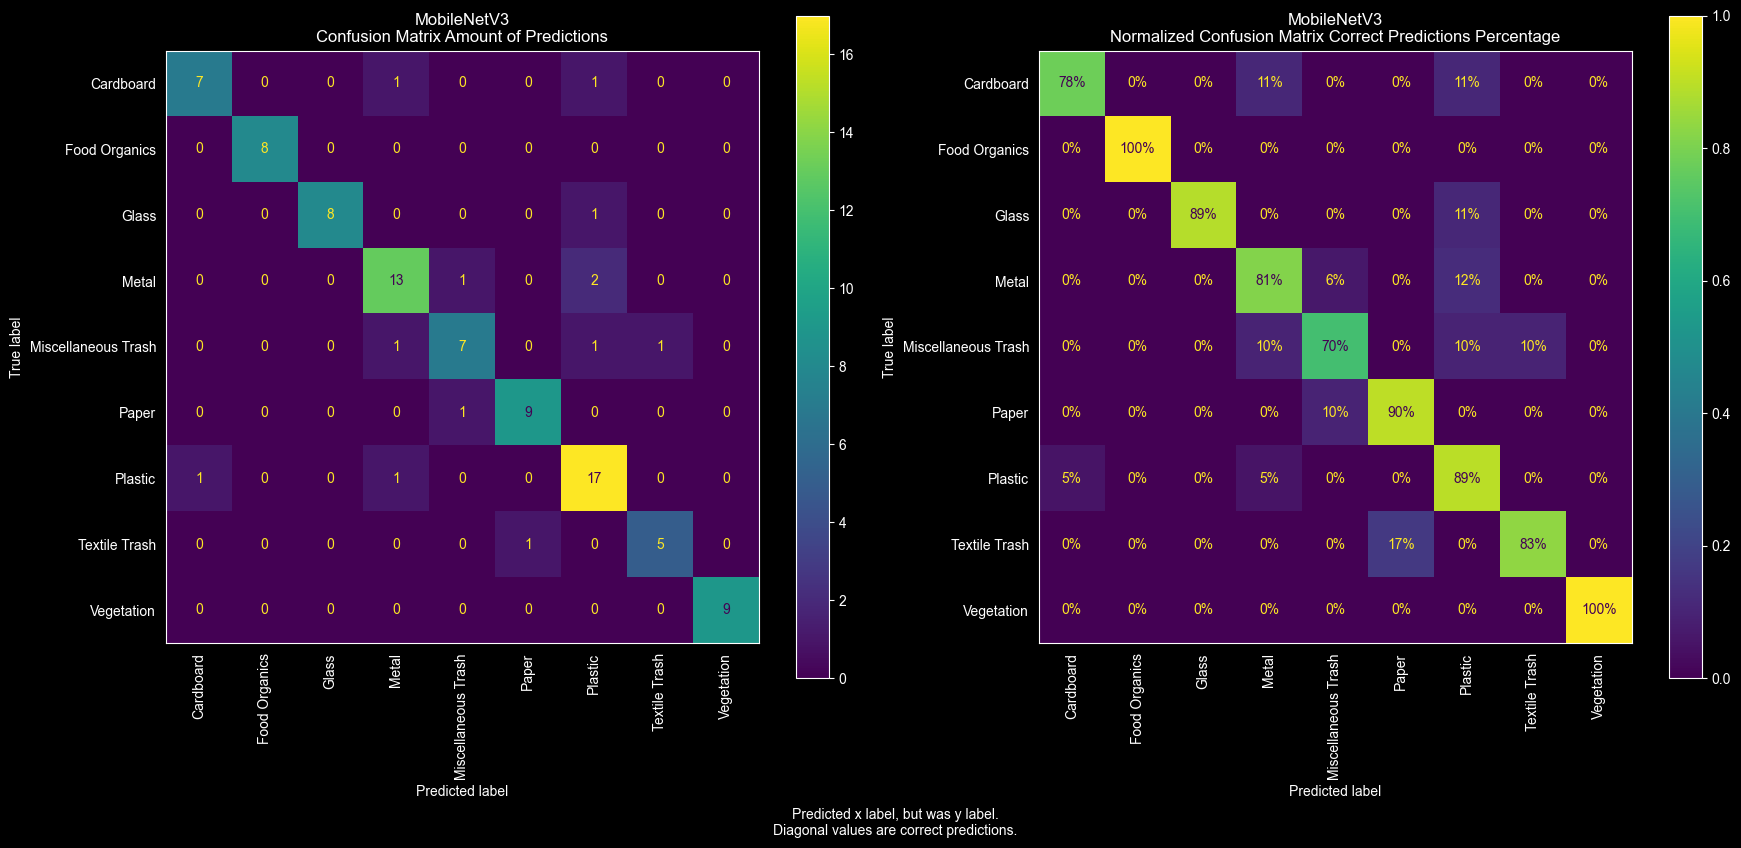

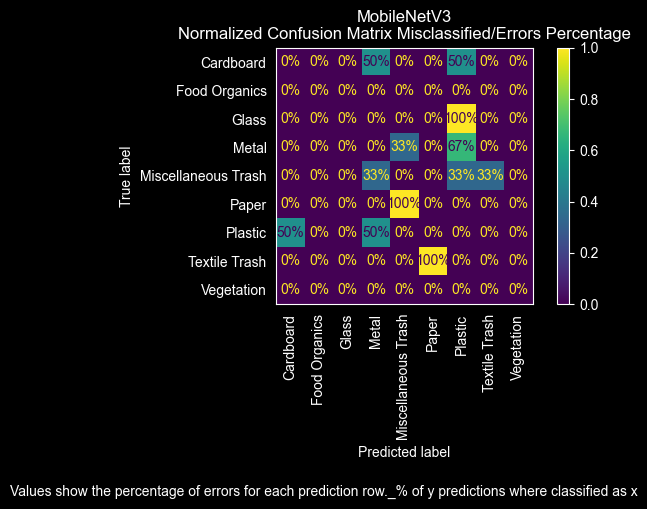

In [38]:
print_confusion_matrix(y_true, y_pred, class_names, mnv3_model.__class__.__name__)

#### Display Performance Table

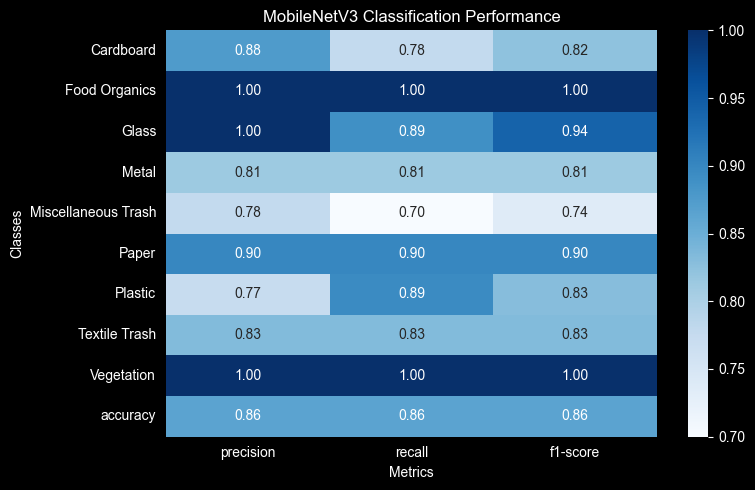

In [39]:
print_performance_table(y_true, y_pred, class_names, mnv3_model.__class__.__name__)

#### Display Top-k Accuracy

In [84]:
mv3_top1, mv3_top5 = get_top_k_accuracy(mnv3_model, test, device)

### EfficientNetB0

#### Load Model

In [73]:
# Create model to load weights
eff_model = torchvision.models.efficientnet_b0(weights=None, num_classes=len(class_names))
# Load checkpoint
model_path = 'models/efficientnet_b0_realwaste.pth'
checkpoint = torch.load(model_path, weights_only=False)
# Load model with the previous saved state
eff_model.load_state_dict(checkpoint['model_state_dict'])
eff_config = checkpoint['config']
eff_model.eval();

#### Test Model

In [87]:
y_true, y_pred = test_model(eff_model, test, eff_config,class_names, device)

Test Loss: 0.694473

Test Accuracy of Cardboard: 71% (33/46)
Test Accuracy of Food Organics: 92% (38/41)
Test Accuracy of Glass: 80% (34/42)
Test Accuracy of Metal: 88% (70/79)
Test Accuracy of Miscellaneous Trash: 42% (21/50)
Test Accuracy of Paper: 76% (38/50)
Test Accuracy of Plastic: 74% (69/93)
Test Accuracy of Textile Trash: 78% (25/32)
Test Accuracy of Vegetation: 95% (41/43)

Test Accuracy (Overall): 77% (369/476)


#### Display Confusion Matrix

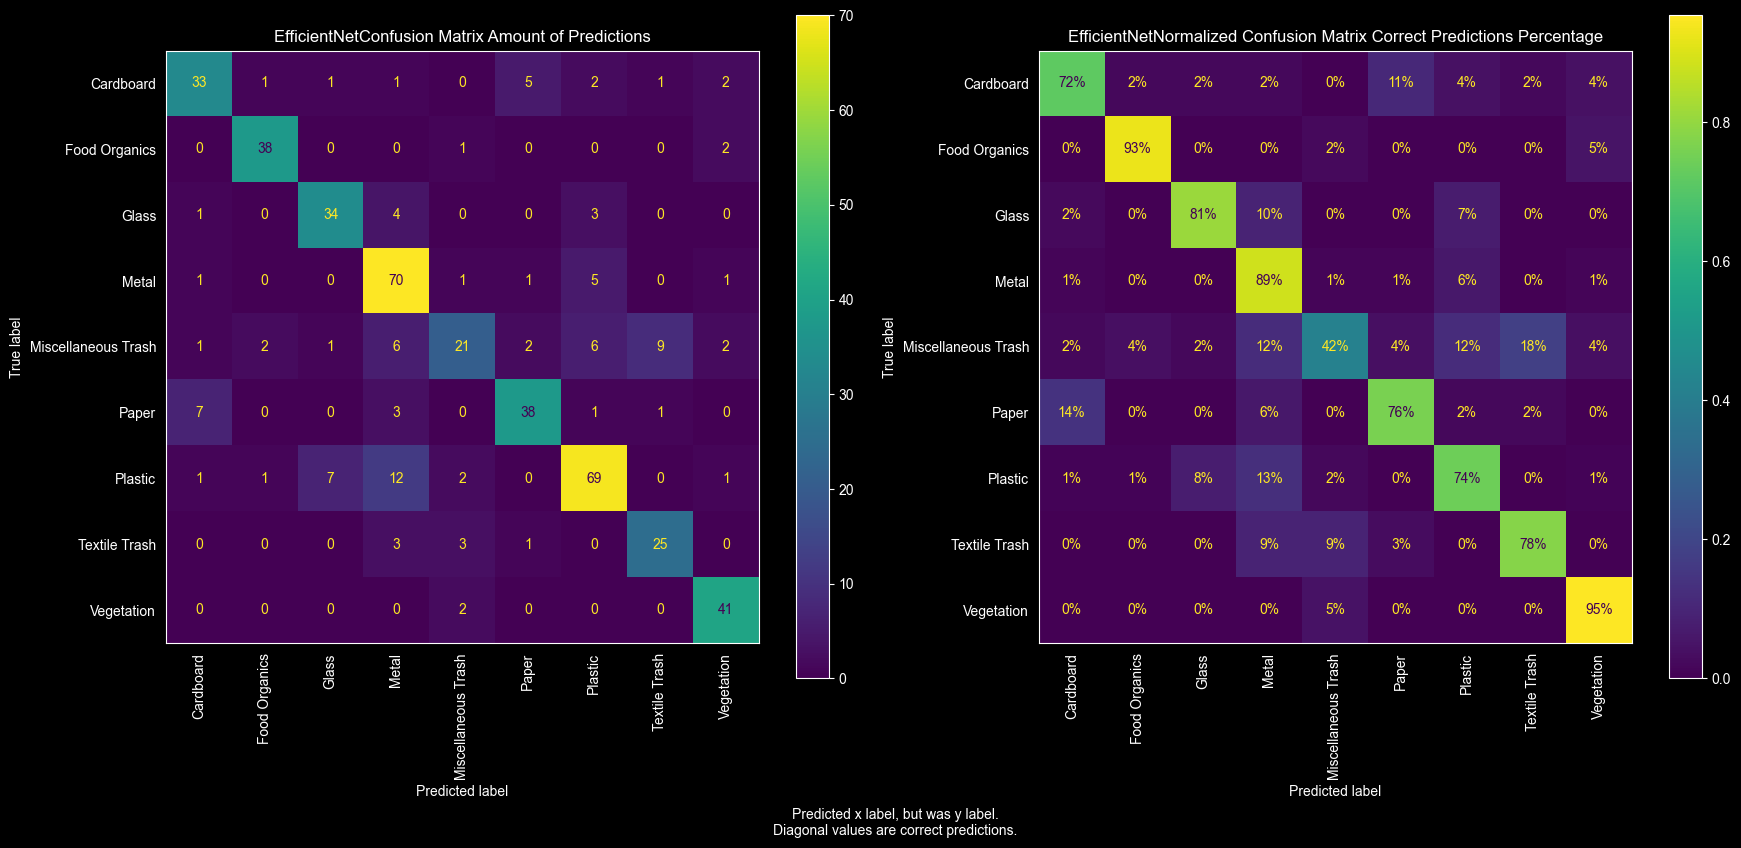

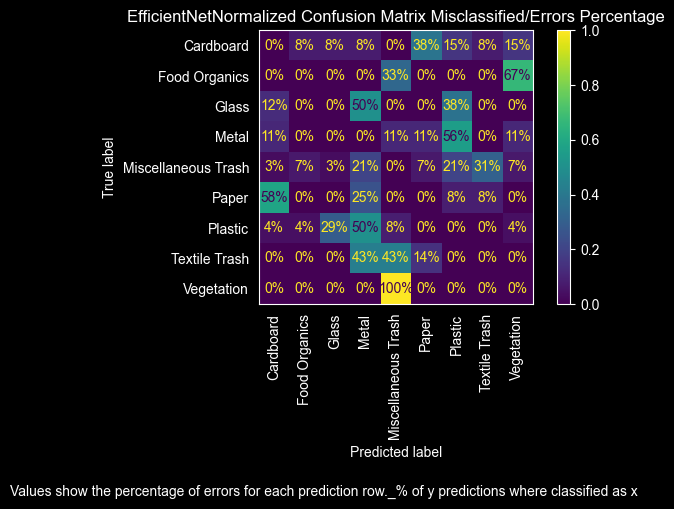

In [88]:
print_confusion_matrix(y_true, y_pred, class_names, eff_model.__class__.__name__)

#### Display Performance Table

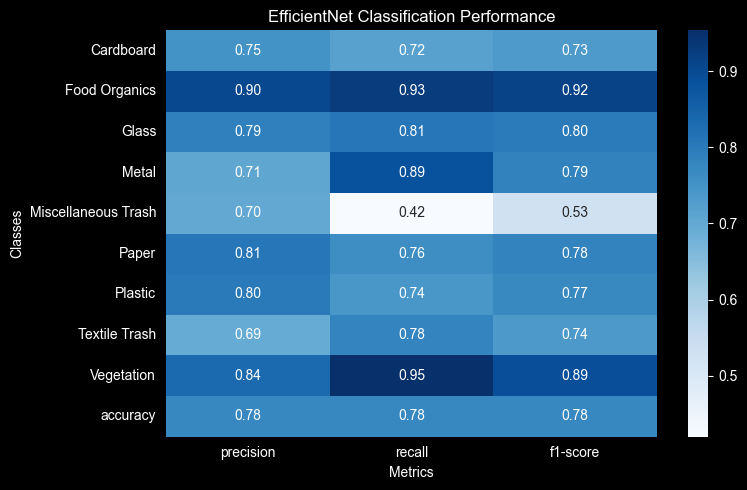

In [89]:
print_performance_table(y_true, y_pred, class_names, eff_model.__class__.__name__)

#### Display Top-k Accuracy

In [90]:
eff_top1, eff_top5 = get_top_k_accuracy(eff_model, test, device)

### GoogleNet

#### Load Model

In [75]:
# Create model to load weights
gn_model = torchvision.models.googlenet(weights=None, num_classes=len(class_names), aux_logits=False)
# Load checkpoint
model_path = 'models/best_googlenet_realwaste.pth'
checkpoint = torch.load(model_path, weights_only=False)
# Load model with the previous saved state
gn_model.load_state_dict(checkpoint['model_state_dict'])
gn_model.eval()
gn_config = checkpoint['config']

#### Test Model

In [57]:
y_true, y_pred = test_model(gn_model, test, gn_config,class_names, device)

Test Loss: 0.400968

Test Accuracy of Cardboard: 97% (45/46)
Test Accuracy of Food Organics: 97% (40/41)
Test Accuracy of Glass: 88% (37/42)
Test Accuracy of Metal: 91% (72/79)
Test Accuracy of Miscellaneous Trash: 76% (38/50)
Test Accuracy of Paper: 84% (42/50)
Test Accuracy of Plastic: 79% (74/93)
Test Accuracy of Textile Trash: 81% (26/32)
Test Accuracy of Vegetation: 97% (42/43)

Test Accuracy (Overall): 87% (416/476)


#### Display Confusion Metrix

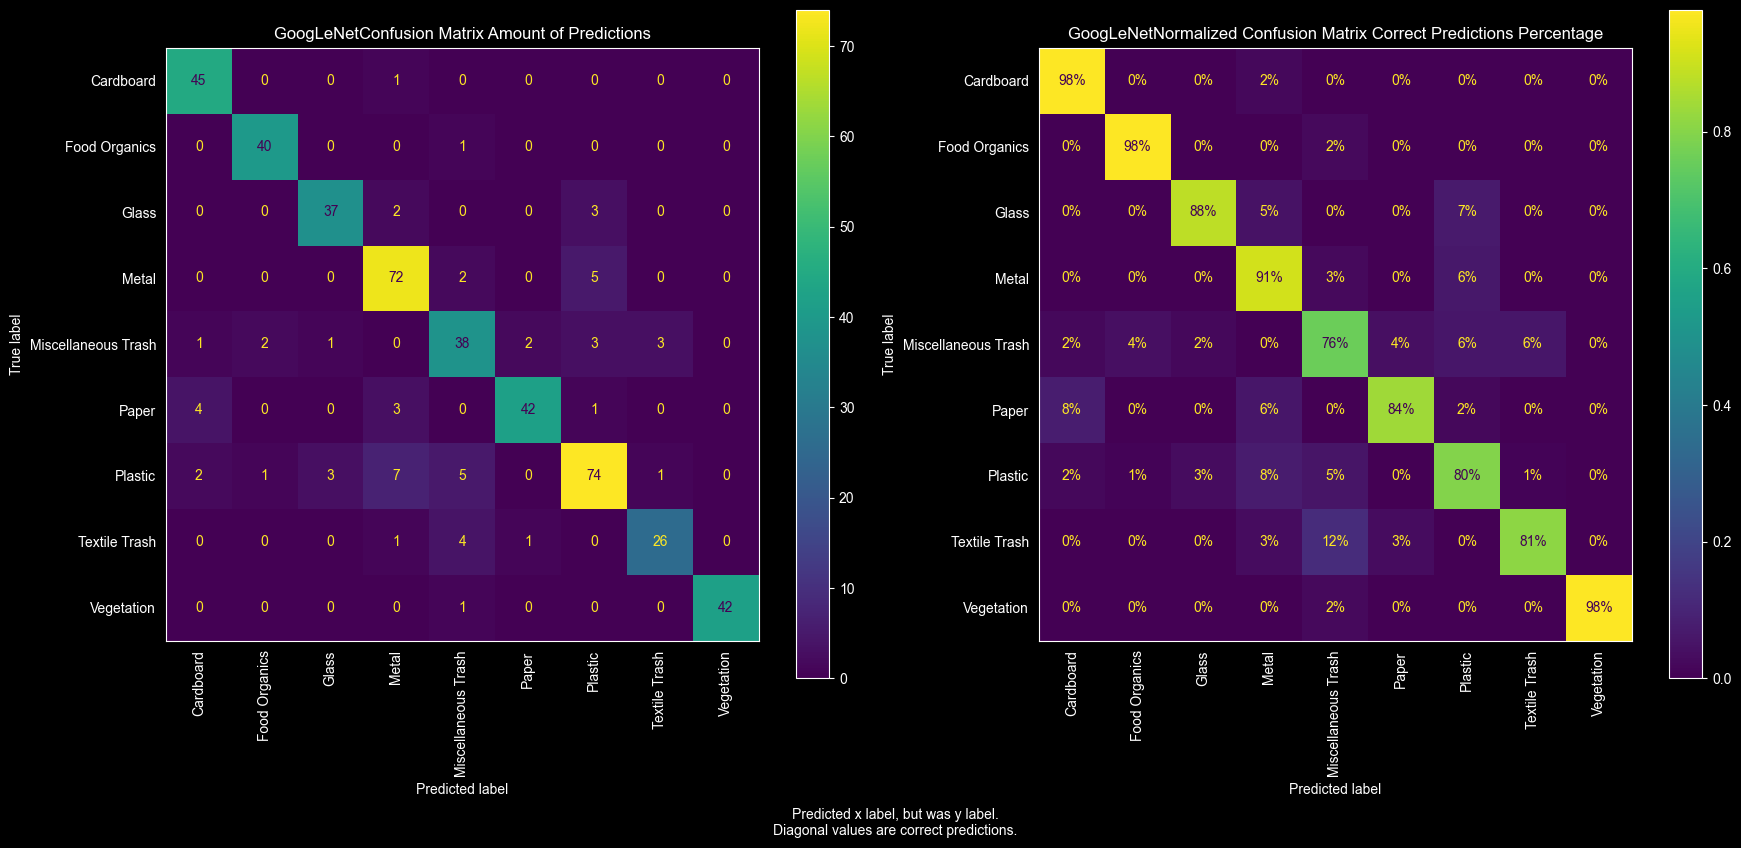

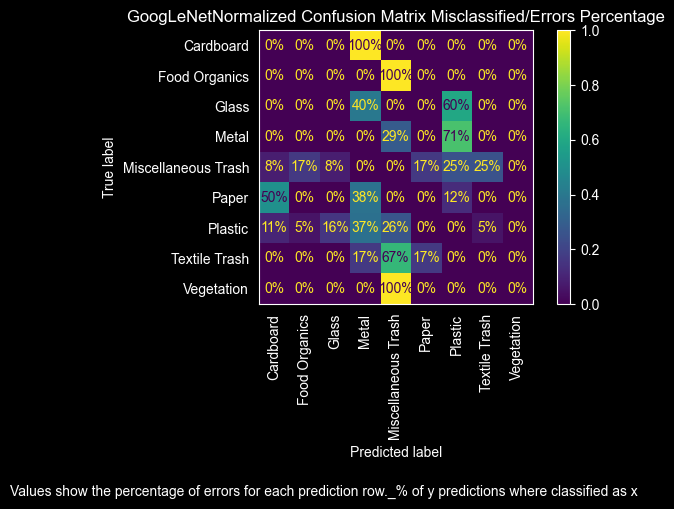

In [58]:
print_confusion_matrix(y_true, y_pred, class_names, gn_model.__class__.__name__)

#### Display Performance Table

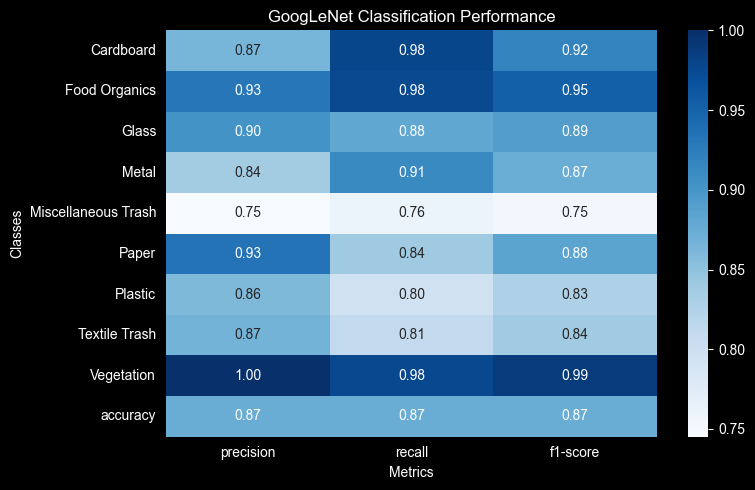

In [59]:
print_performance_table(y_true, y_pred, class_names, gn_model.__class__.__name__)

Display Tok-K Accuracy

In [61]:
gn_top1, gn_top5 = get_top_k_accuracy(gn_model, test, device)

### Compare Results

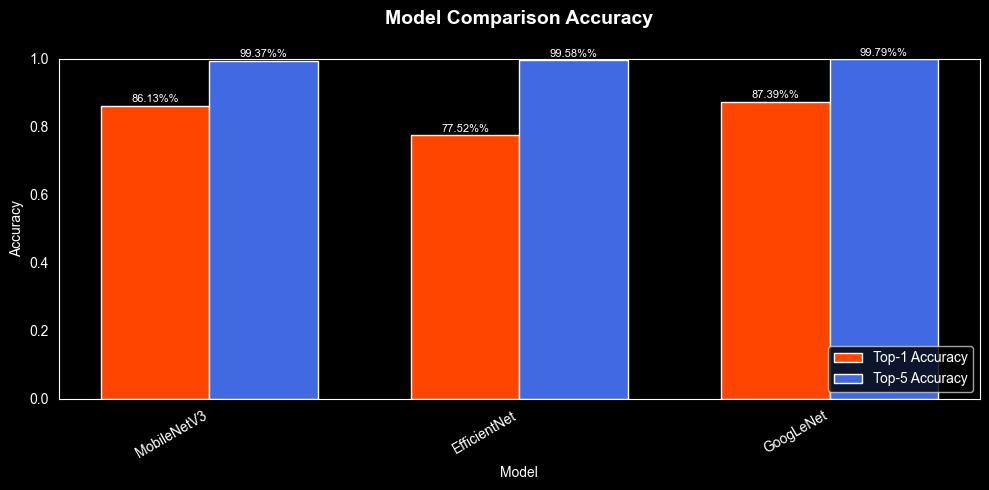

In [77]:
model_names = [mnv3_model.__class__.__name__, eff_model.__class__.__name__, gn_model.__class__.__name__]
accuracy_scores = [(mv3_top1, mv3_top5), (eff_top1, eff_top5), (gn_top1, gn_top5)]

plot_all_models_accuracy(model_names, accuracy_scores)